<a href="https://colab.research.google.com/github/jhljoel/curso-inteligencia-artificial/blob/main/EDA_Cars_2025_tarea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA) — Cars Dataset 2025


## 0. Importación de Librerías

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

---
## Preguntas Generales — Tipos de Datos y Estadística Descriptiva

In [52]:
df = pd.read_csv('drive/MyDrive/inteligencia artificial/Cars Datasets 2025.csv', encoding='latin1')
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')

Dimensiones del dataset: 1218 filas × 11 columnas


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [55]:
df.tail()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219  302 hp,200 km/h,6.0  8.1 sec,"$29,000  $43,000",Hybrid / Plug-in,5,221  400 Nm


In [56]:
df.dtypes


,0
Company Names,object
Cars Names,object
Engines,object
CC/Battery Capacity,object
HorsePower,object
Total Speed,object
Performance(0 - 100 )KM/H,object
Cars Prices,object
Fuel Types,object
Seats,object


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


In [58]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,unique,top,freq
Company Names,1218,37,Nissan,149
Cars Names,1218,1201,Mistral,2
Engines,1218,356,I4,64
CC/Battery Capacity,1215,311,1984 cc,31
HorsePower,1218,456,355 hp,23
Total Speed,1218,114,250 km/h,145
Performance(0 - 100 )KM/H,1212,180,6.5 sec,45
Cars Prices,1218,535,"$35,000",36
Fuel Types,1218,23,Petrol,871
Seats,1218,19,5,692


In [59]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')
if cat_cols:
    df[cat_cols].describe().T

Variables categóricas (11): ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque']


In [60]:
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()}')

  Company Names: 37
  Cars Names: 1201
  Engines: 356
  CC/Battery Capacity: 311
  HorsePower: 456
  Total Speed: 114
  Performance(0 - 100 )KM/H: 180
  Cars Prices: 535
  Fuel Types: 23
  Seats: 19
  Torque: 263


---
## Análisis de Datos Nulos (Data Cleaning)

In [61]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('Análisis de valores nulos:')
display(nulos[nulos['Nulos'] > 0])
print(f'\nTotal de celdas nulas: {df.isnull().sum().sum()}')
print(f'Porcentaje total de nulos: {(df.isnull().sum().sum() / df.size * 100):.2f}%')

Análisis de valores nulos:


,Nulos,Porcentaje (%)
Performance(0 - 100 )KM/H,6,0.49
CC/Battery Capacity,3,0.25
Torque,1,0.08



Total de celdas nulas: 10
Porcentaje total de nulos: 0.07%


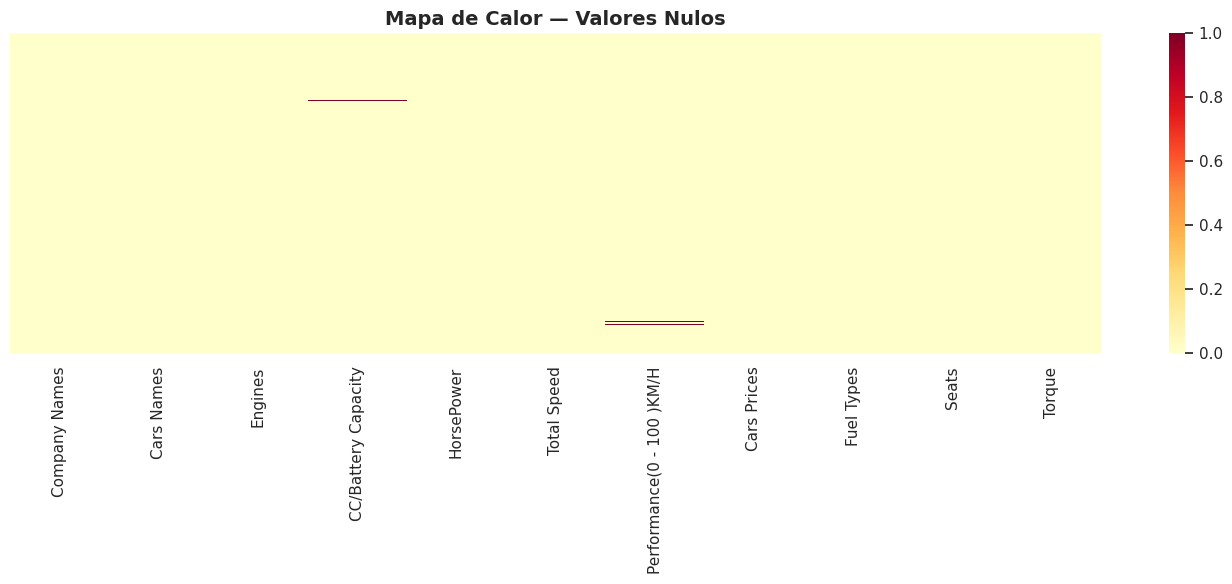

In [62]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Mapa de Calor — Valores Nulos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.2f}%)')
if duplicados > 0:
    display(df[df.duplicated()])

Filas duplicadas: 4 (0.33%)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
336,Volkswagen,Golf Cabriolet,1.2L I4 Turbo / 2.0L I4 Turbo,1197 cc / 1984 cc,105 - 210 hp,217 km/h,8.4 sec,"$30,000",Petrol,4,200 Nm
354,Volkswagen,Jetta Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,170 hp,210 km/h,8.6 sec,"$28,000",Hybrid,5,250 Nm
658,Tata Motors,Tiago EV,Permanent Magnet Synchronous,24 kWh,74 hp,120 km/h,5.7 sec,"$11,000",Electric,5,114 Nm
755,Chevrolet,Tahoe RST,5.3L V8 Gasoline,5300 cc,355 hp,180 km/h,7.4 sec,"$64,100",Petrol,7,519 Nm


In [64]:
df_clean = df.drop_duplicates().copy()
def clean_numeric_column(series):
    s = series.astype(str).str.lower()

    if series.name == 'Cars Prices':
        s = s.str.replace('$', '', regex=False).str.replace('€', '', regex=False).str.replace(',', '', regex=False).str.replace(' ', '', regex=False)

    s = s.str.replace('hp', '', regex=False)
    s = s.str.replace('km/h', '', regex=False)
    s = s.str.replace('sec', '', regex=False)
    s = s.str.replace('cc', '', regex=False)
    s = s.str.replace('nm', '', regex=False)
    s = s.str.replace('battery', '', regex=False)
    s = s.str.replace('hybrid', '', regex=False)
    s = s.str.replace('batt', '', regex=False)

    def parse_range_or_single(val):
        if '' in val: # special character used in the data
            parts = val.split('')
            try:
                nums = [float(p.strip()) for p in parts]
                return np.mean(nums)
            except ValueError:
                return np.nan
        elif '-' in val: # standard hyphen
            parts = val.split('-')
            try:
                nums = [float(p.strip()) for p in parts]
                return np.mean(nums)
            except ValueError:
                return np.nan
        else:
            try:
                return float(val.strip())
            except ValueError:
                return np.nan

    return s.apply(parse_range_or_single)

# Columns to convert
numeric_cols_to_convert = [
    'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H',
    'Cars Prices', 'CC/Battery Capacity', 'Torque'
]

print('\nConvirtiendo columnas a tipo numérico:')
for col in numeric_cols_to_convert:
    df_clean[col] = clean_numeric_column(df_clean[col])
    print(f'  Columna [{col}] convertida.')

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

print('\nImputando valores nulos:')
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f'  Numérica [{col}]: imputada con mediana = {mediana:.2f}')

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f'  Categórica [{col}]: imputada con moda = {moda}')



Convirtiendo columnas a tipo numérico:
  Columna [HorsePower] convertida.
  Columna [Total Speed] convertida.
  Columna [Performance(0 - 100 )KM/H] convertida.
  Columna [Cars Prices] convertida.
  Columna [CC/Battery Capacity] convertida.
  Columna [Torque] convertida.

Imputando valores nulos:
  Numérica [CC/Battery Capacity]: imputada con mediana = 2700.00
  Numérica [HorsePower]: imputada con mediana = 253.00
  Numérica [Total Speed]: imputada con mediana = 200.00
  Numérica [Performance(0 - 100 )KM/H]: imputada con mediana = 7.10
  Numérica [Cars Prices]: imputada con mediana = 42795.00
  Numérica [Torque]: imputada con mediana = 366.00


---
## Análisis Univariado

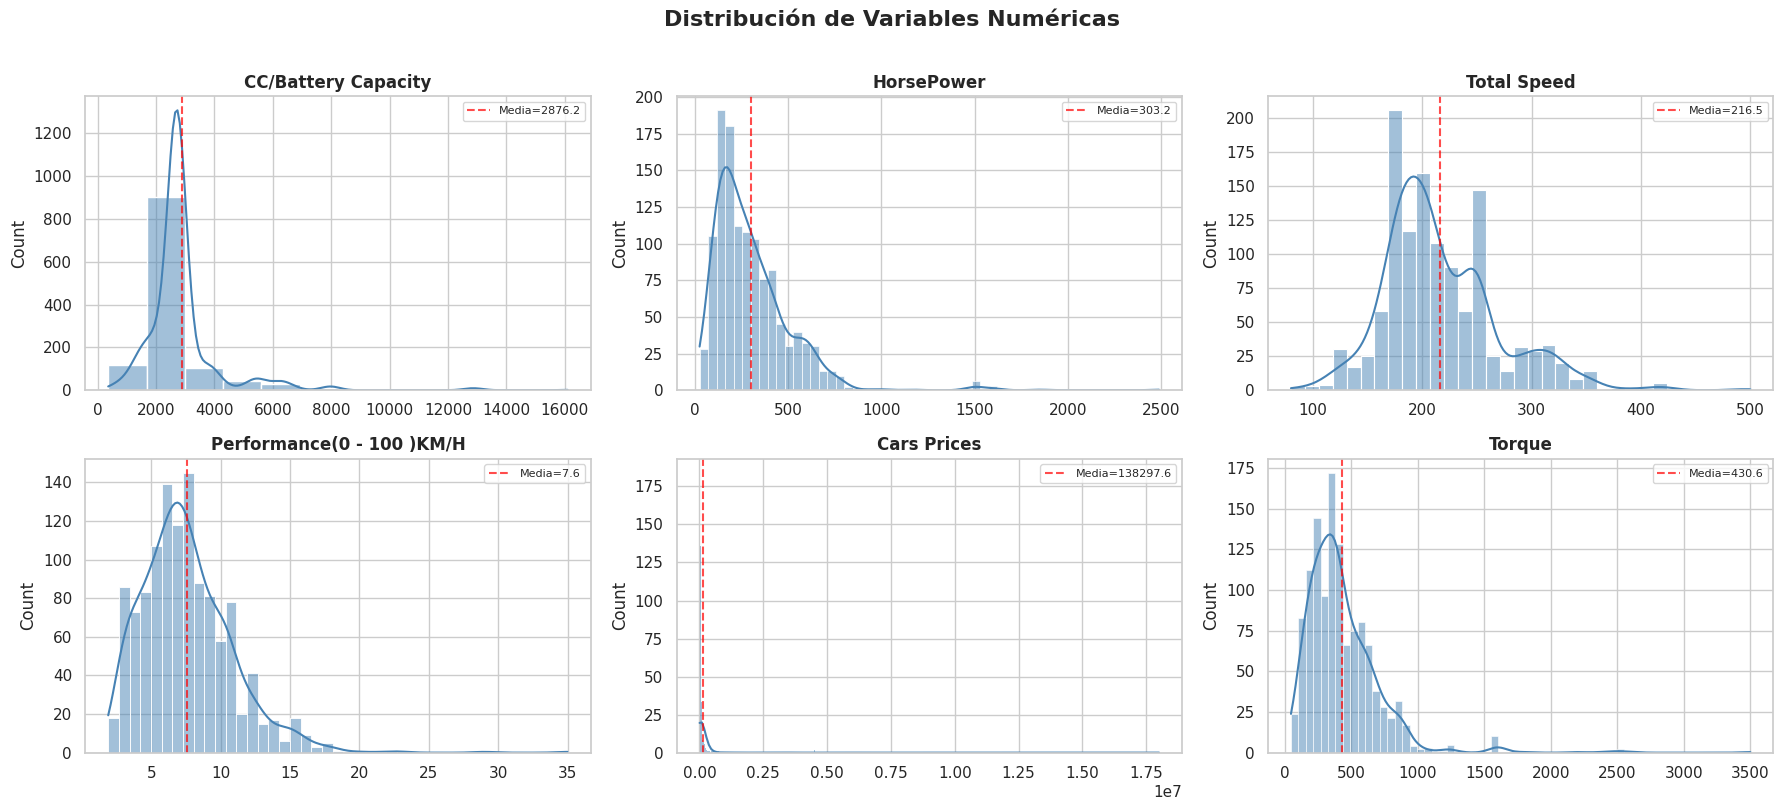

In [65]:
if num_cols:
    n = len(num_cols)
    cols_grid = 3
    rows_grid = (n + cols_grid - 1) // cols_grid
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, rows_grid * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i], color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].set_xlabel('')
        # Estadísticas en el gráfico
        mu = df_clean[col].mean()
        axes[i].axvline(mu, color='red', linestyle='--', alpha=0.7, label=f'Media={mu:.1f}')
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

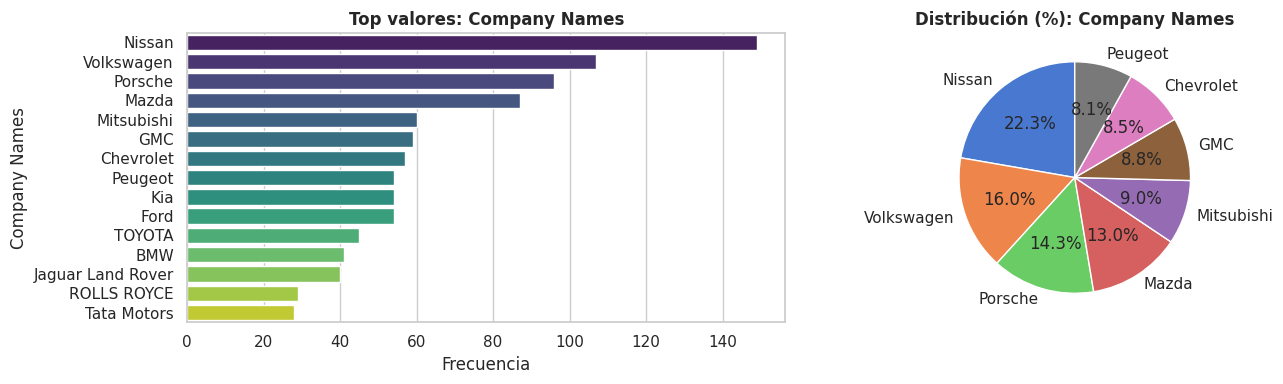

  Valores únicos: 37



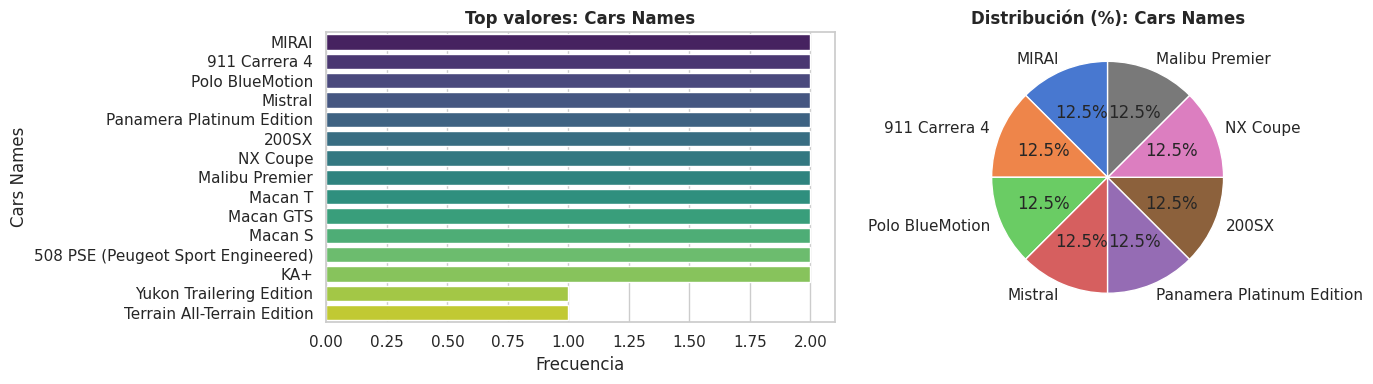

  Valores únicos: 1201



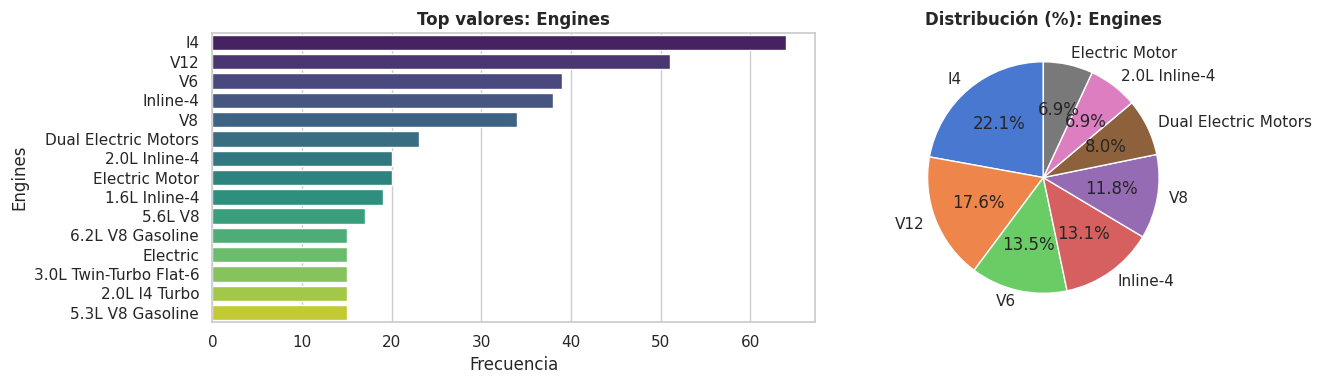

  Valores únicos: 356



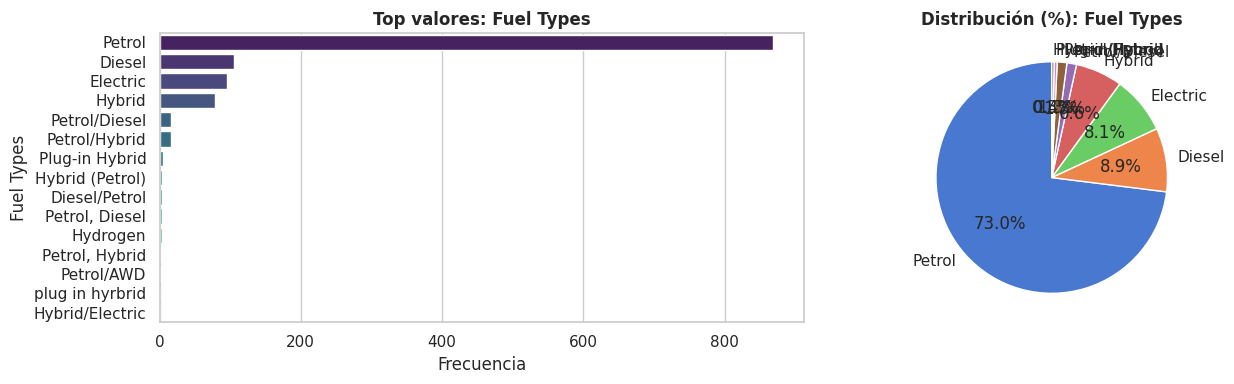

  Valores únicos: 23



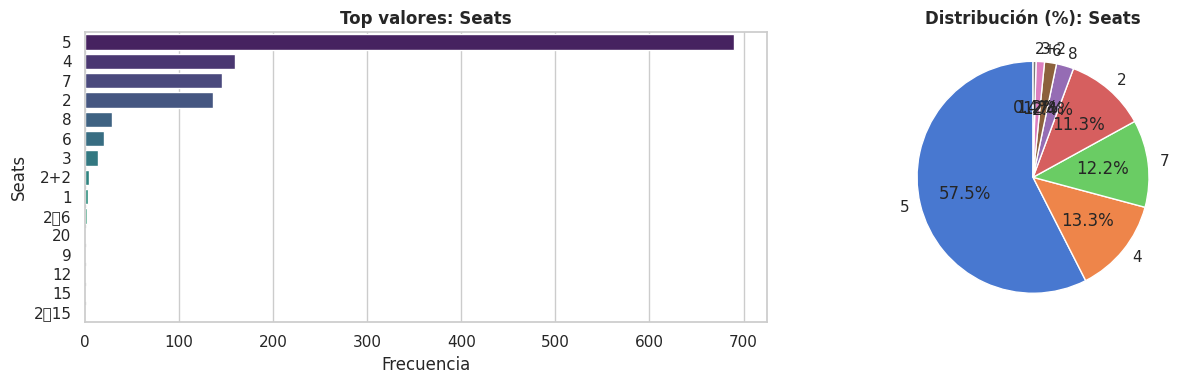

  Valores únicos: 19



In [66]:
for col in cat_cols:
    freq = df_clean[col].value_counts().head(15)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.barplot(x=freq.values, y=freq.index, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Top valores: {col}', fontweight='bold')
    axes[0].set_xlabel('Frecuencia')

    freq_pie = df_clean[col].value_counts().head(8)
    axes[1].pie(freq_pie.values, labels=freq_pie.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Distribución (%): {col}', fontweight='bold')

    plt.tight_layout()
    plt.show()
    print(f'  Valores únicos: {df_clean[col].nunique()}\n')

---
## Análisis de Datos Atípicos

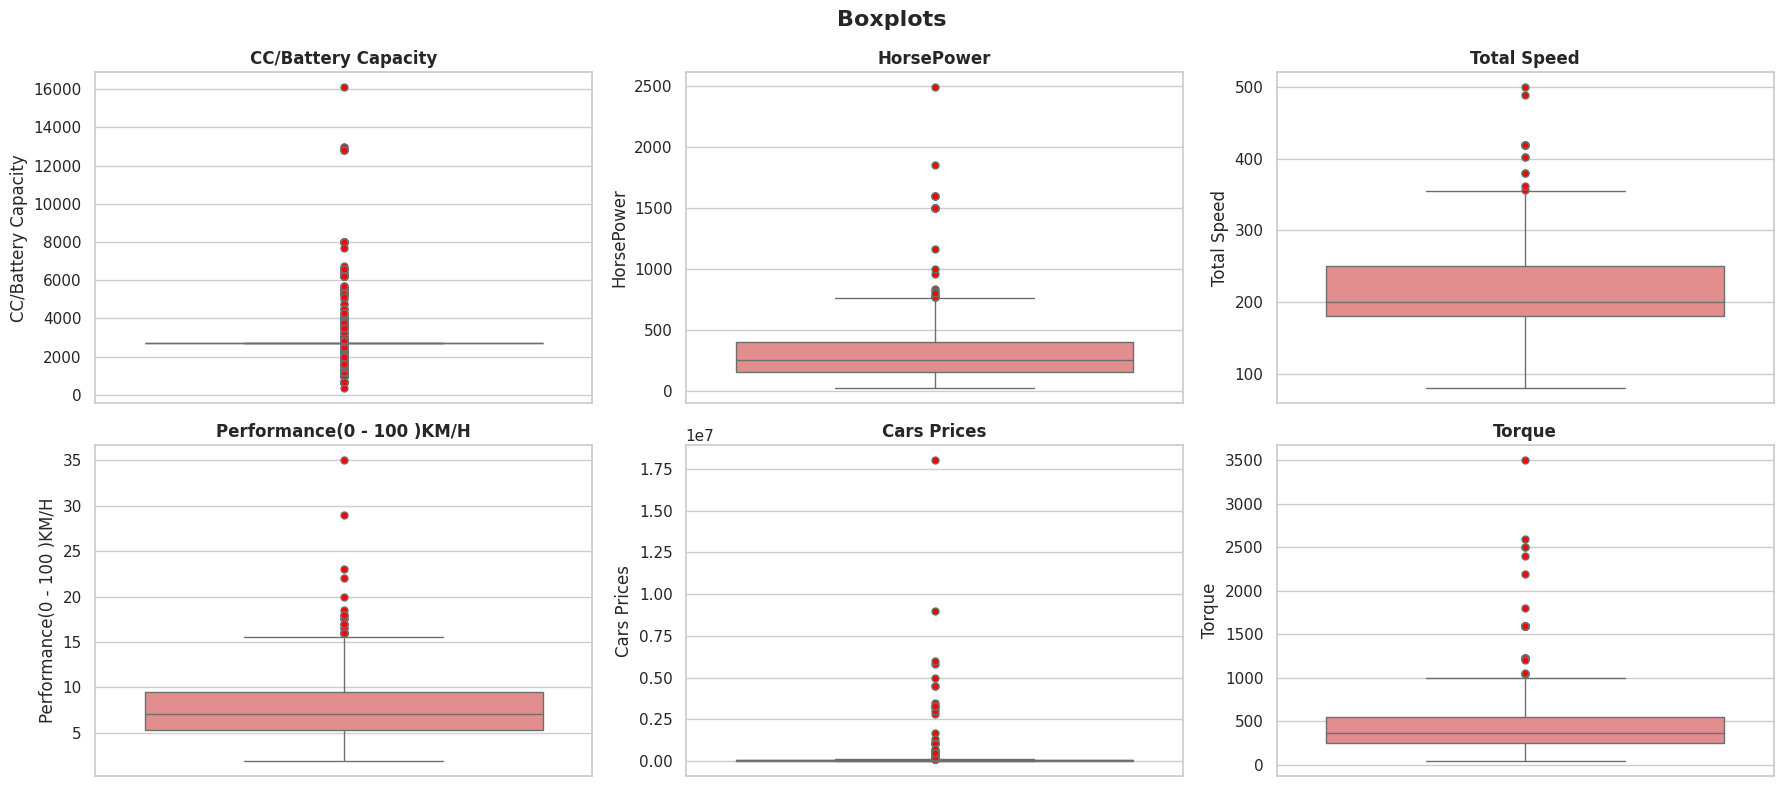

In [67]:
if num_cols:
    n = len(num_cols)
    cols_grid = 3
    rows_grid = (n + cols_grid - 1) // cols_grid
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, rows_grid * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(y=df_clean[col].dropna(), ax=axes[i], color='lightcoral',
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
        axes[i].set_title(f'{col}', fontweight='bold')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [68]:
print('Outliers por método IQR (1.5×IQR):\n')
outlier_summary = []

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = n_out / len(df_clean) * 100
    outlier_summary.append({
        'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'Límite Inferior': round(lower, 2), 'Límite Superior': round(upper, 2),
        'N Outliers': n_out, '% Outliers': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('N Outliers', ascending=False)
display(outlier_df.style.background_gradient(subset=['N Outliers', '% Outliers'], cmap='Reds'))

Outliers por método IQR (1.5×IQR):



,Variable,Q1,Q3,Límite Inferior,Límite Superior,N Outliers,% Outliers
0,CC/Battery Capacity,2700.000000,2700.000000,2700.000000,2700.000000,488,40.200000
4,Cars Prices,28000.000000,70000.000000,-35000.000000,133000.000000,148,12.190000
5,Torque,250.000000,550.000000,-200.000000,1000.000000,26,2.140000
3,Performance(0 - 100 )KM/H,5.300000,9.500000,-1.000000,15.800000,23,1.890000
1,HorsePower,155.000000,400.000000,-212.500000,767.500000,22,1.810000
2,Total Speed,180.000000,250.000000,75.000000,355.000000,13,1.070000


In [69]:
for col in num_cols:
    z = np.abs(stats.zscore(df_clean[col].dropna()))
    n_out = (z > 3).sum()
    if n_out > 0:
        print(f'  {col}: {n_out} outliers extremos ({n_out/len(df_clean)*100:.2f}%)')

  CC/Battery Capacity: 18 outliers extremos (1.48%)
  HorsePower: 14 outliers extremos (1.15%)
  Total Speed: 11 outliers extremos (0.91%)
  Performance(0 - 100 )KM/H: 11 outliers extremos (0.91%)
  Cars Prices: 14 outliers extremos (1.15%)
  Torque: 17 outliers extremos (1.40%)


---
## Análisis Bivariado

In [70]:
possible_targets = ['price', 'Price', 'precio', 'Precio', 'PRICE', 'value', 'Value']
target_col = next((c for c in possible_targets if c in df_clean.columns), num_cols[0] if num_cols else None)
print(f'🎯 Variable objetivo detectada: {target_col}')
print('   (Cambia target_col manualmente si es necesario)')

🎯 Variable objetivo detectada: CC/Battery Capacity
   (Cambia target_col manualmente si es necesario)


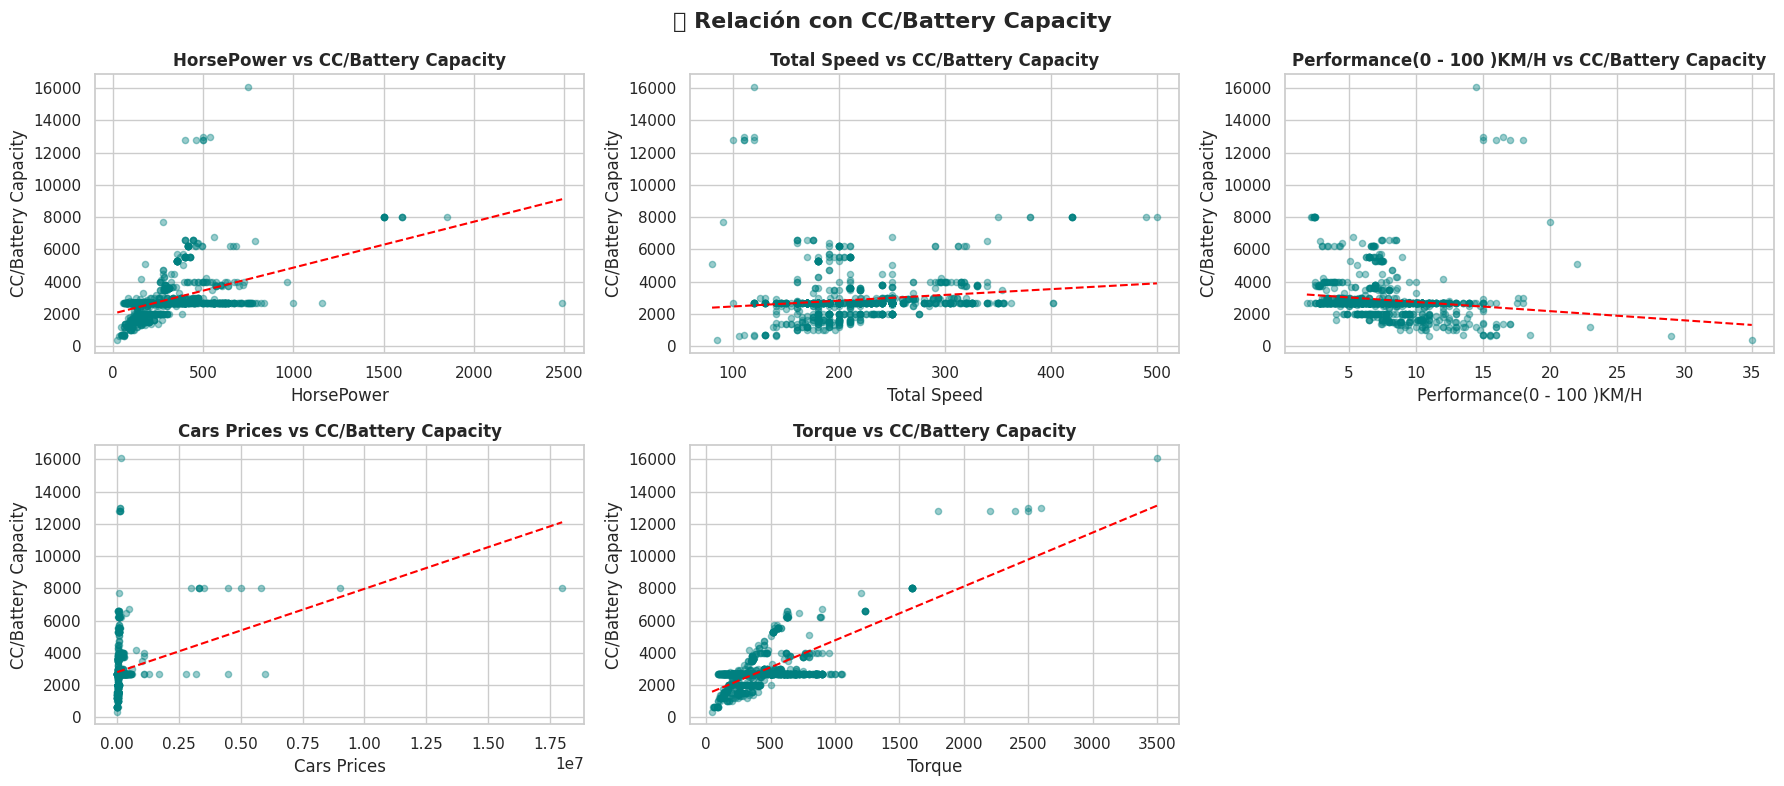

In [71]:
# Scatterplots: numérica vs variable objetivo
if target_col and len(num_cols) > 1:
    other_num = [c for c in num_cols if c != target_col]
    n = len(other_num)
    cols_grid = 3
    rows_grid = (n + cols_grid - 1) // cols_grid
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, rows_grid * 4))
    axes = axes.flatten()

    for i, col in enumerate(other_num):
        axes[i].scatter(df_clean[col], df_clean[target_col], alpha=0.4, color='teal', s=20)
        # Línea de tendencia
        m, b = np.polyfit(df_clean[col].dropna(), df_clean[target_col].dropna(), 1) if df_clean[col].notna().all() else (0, 0)
        x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
        axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{col} vs {target_col}', fontweight='bold')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'🔵 Relación con {target_col}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

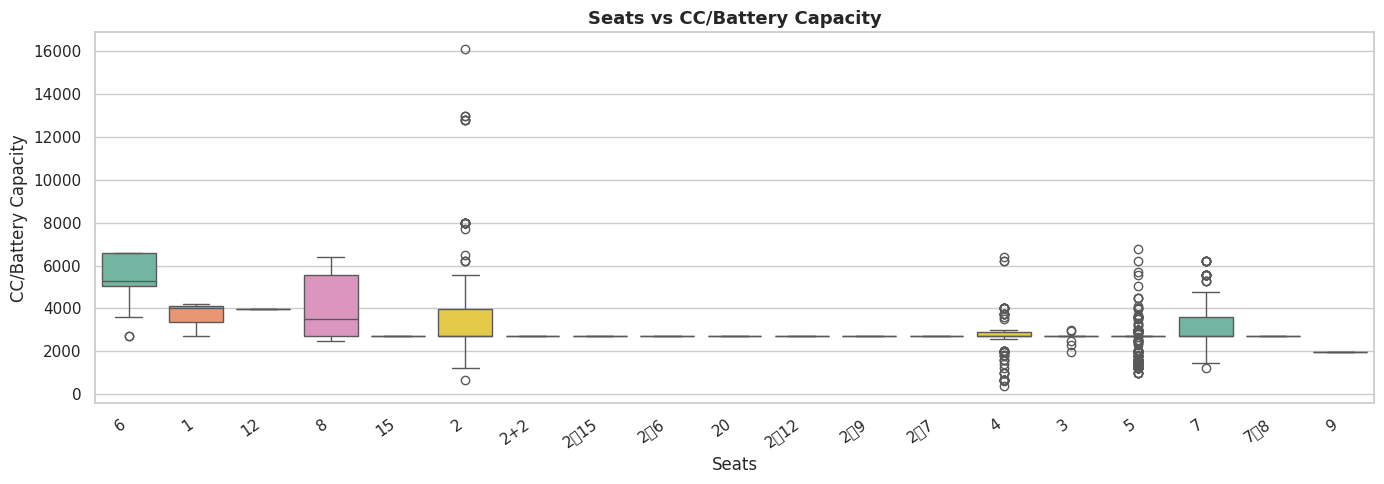

In [72]:
if target_col:
    cat_low = [c for c in cat_cols if df_clean[c].nunique() <= 20]
    for col in cat_low[:4]:  # Máx 4 para no saturar
        fig, ax = plt.subplots(figsize=(14, 5))
        order = df_clean.groupby(col)[target_col].median().sort_values(ascending=False).index
        sns.boxplot(data=df_clean, x=col, y=target_col, order=order, palette='Set2', ax=ax)
        ax.set_title(f'{col} vs {target_col}', fontsize=13, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
        plt.tight_layout()
        plt.show()

In [73]:
if target_col:
    for col in cat_low[:4]:
        print(f'\n{target_col} promedio por {col}:')
        resumen = df_clean.groupby(col)[target_col].agg(['mean','median','std','count']).round(2)
        resumen.columns = ['Media', 'Mediana', 'Desv.Est.', 'N']
        display(resumen.sort_values('Media', ascending=False))


CC/Battery Capacity promedio por Seats:


,Media,Mediana,Desv.Est.,N
Seats,,,,
6,5367.60,5300.0,1277.79,20
8,4279.03,3500.0,1457.19,29
12,3954.00,3954.0,NaN,1
2,3950.99,2700.0,2713.20,136
1,3630.00,3996.0,811.47,3
7,3186.20,2700.0,1208.62,146
15,2700.00,2700.0,NaN,1
215,2700.00,2700.0,NaN,1
2+2,2700.00,2700.0,0.00,5


---
## Análisis de Correlación

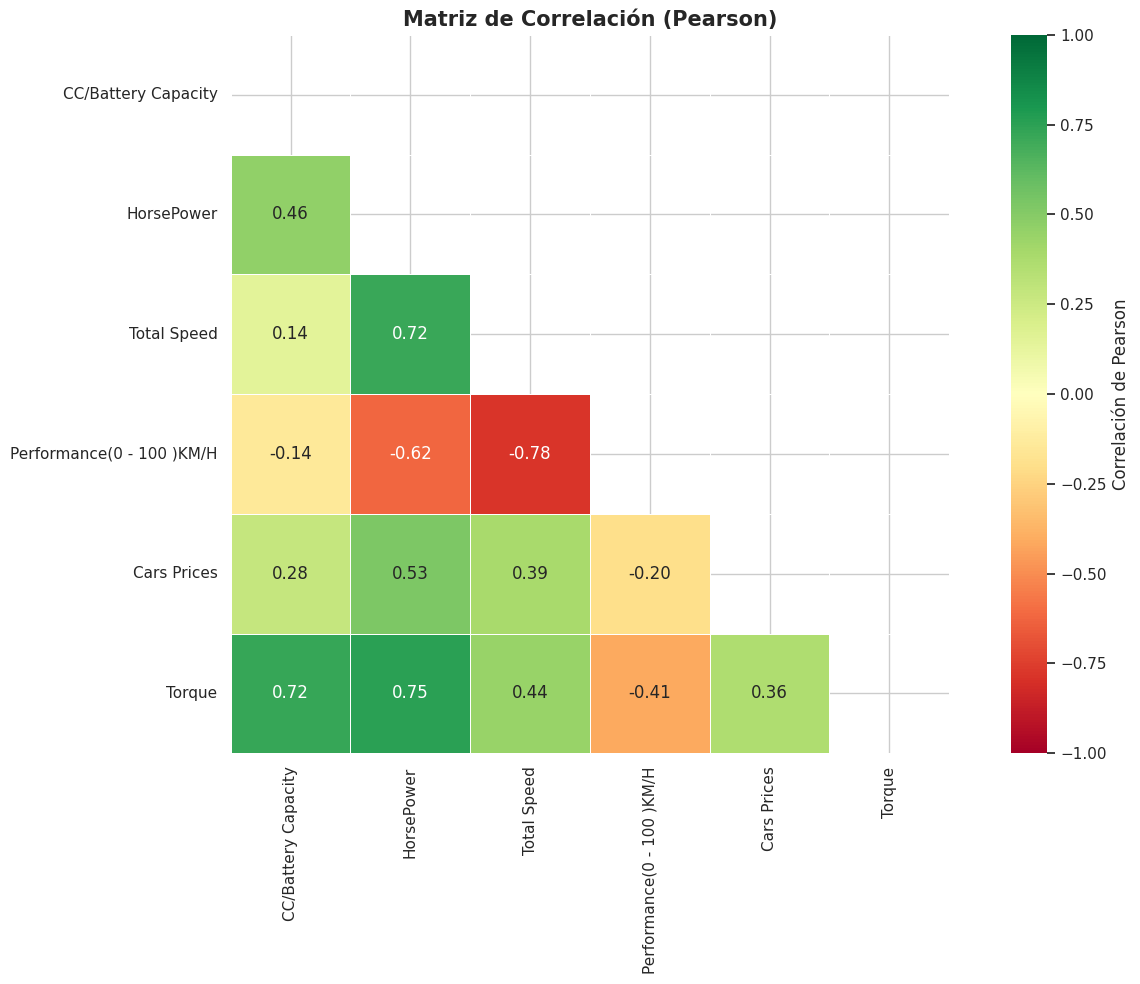

In [74]:
if len(num_cols) > 1:
    corr_matrix = df_clean[num_cols].corr(method='pearson')

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Triangular superior
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'label': 'Correlación de Pearson'}
    )
    plt.title('Matriz de Correlación (Pearson)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

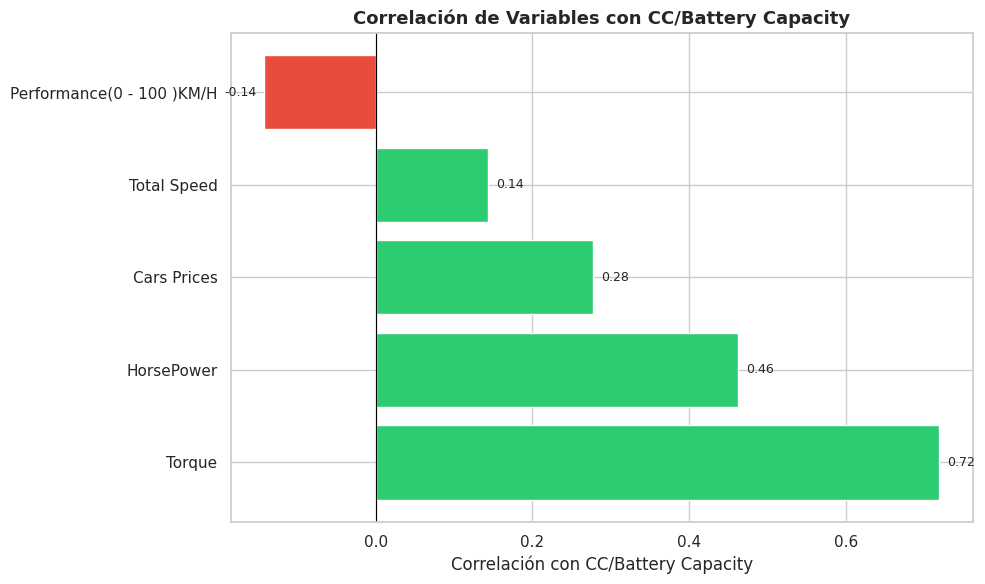


Top correlaciones con CC/Battery Capacity
Torque                       0.719144
HorsePower                   0.462213
Cars Prices                  0.277036
Total Speed                  0.143134
Performance(0 - 100 )KM/H   -0.141780


In [75]:
if target_col and len(num_cols) > 1:
    corr_target = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target.values]
    bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlación con ' + target_col)
    ax.set_title(f'Correlación de Variables con {target_col}', fontsize=13, fontweight='bold')

    for bar, val in zip(bars, corr_target.values):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('\nTop correlaciones con', target_col)
    print(corr_target.to_string())

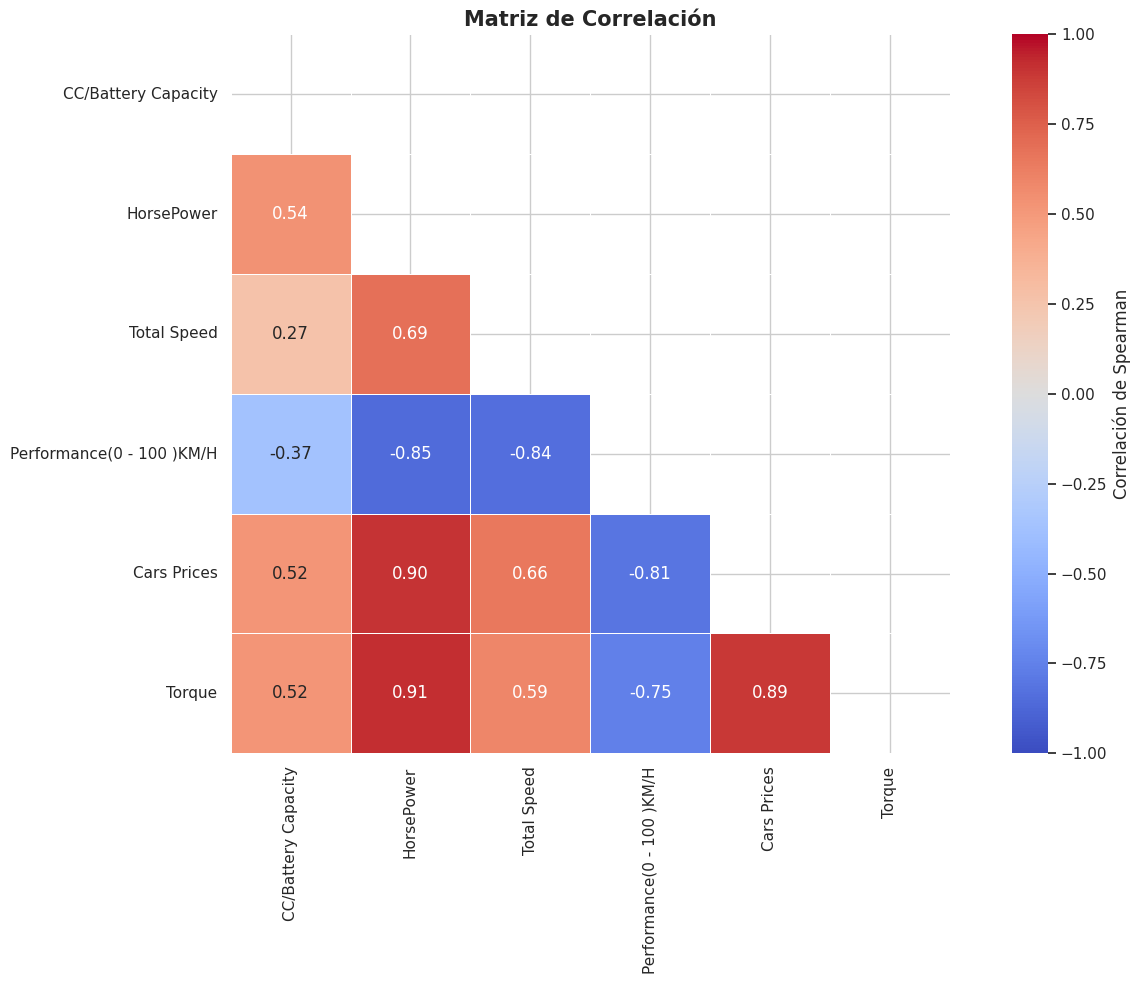

In [76]:
if len(num_cols) > 1:
    corr_spearman = df_clean[num_cols].corr(method='spearman')

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
    sns.heatmap(
        corr_spearman, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'label': 'Correlación de Spearman'}
    )
    plt.title('Matriz de Correlación', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

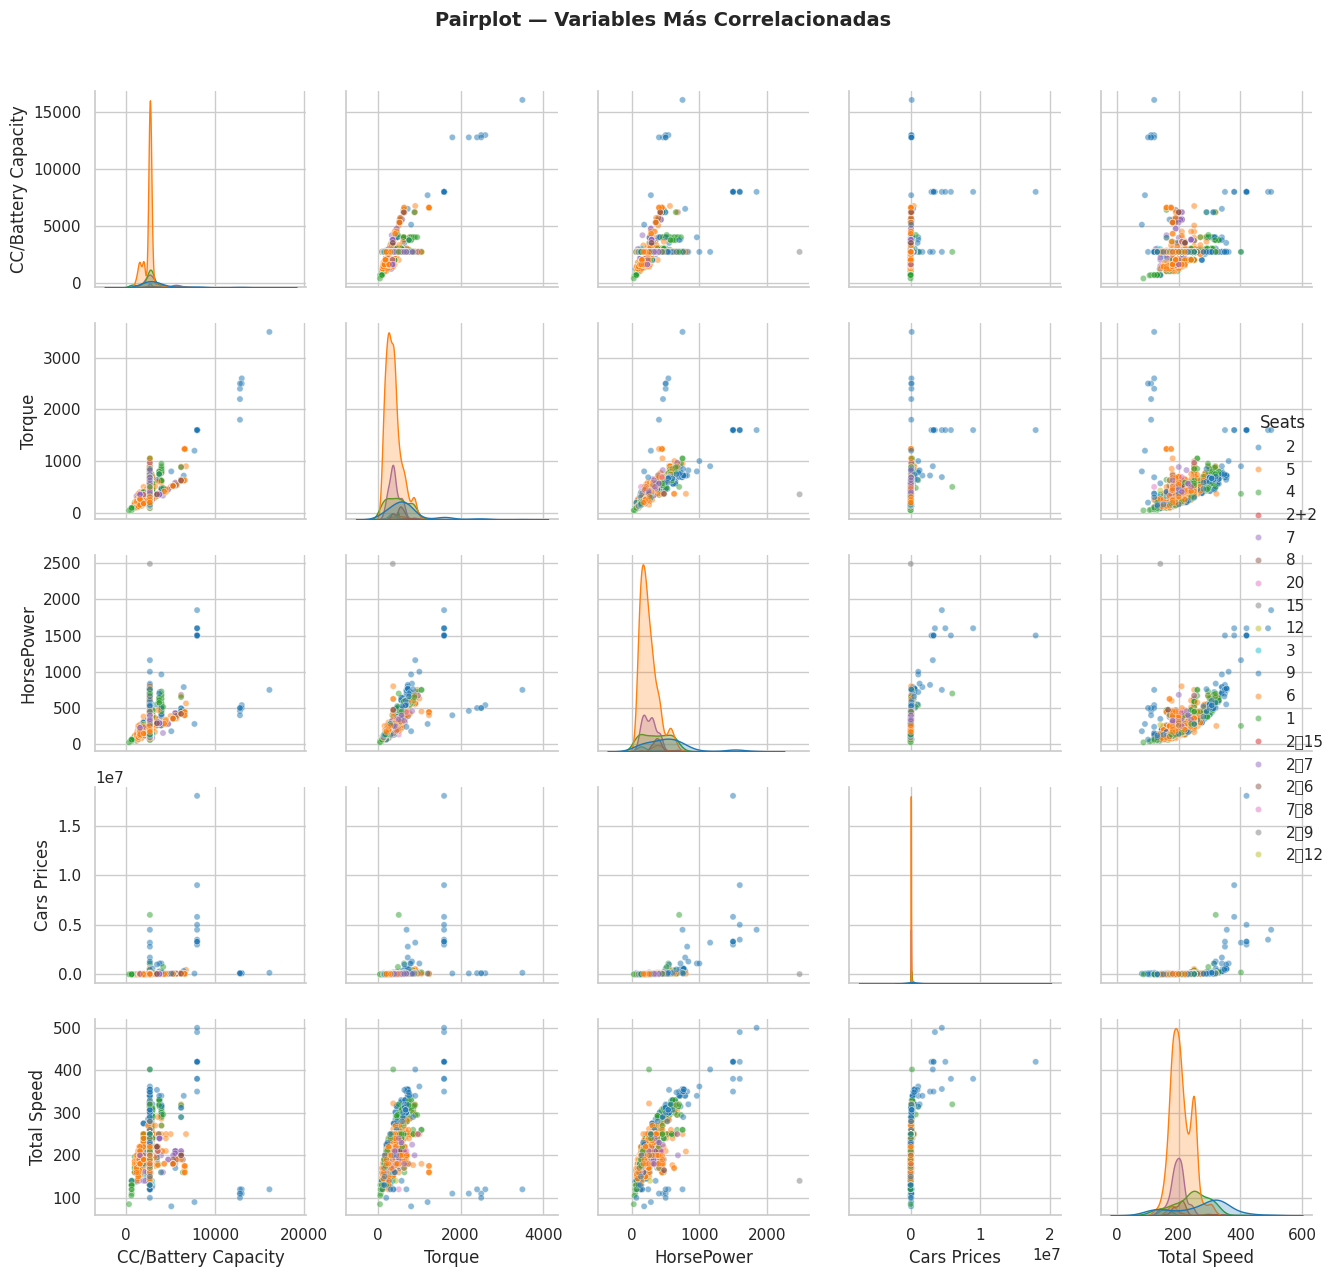

In [77]:
if len(num_cols) >= 2:
    top_vars = corr_target.head(4).index.tolist() if target_col else num_cols[:5]
    if target_col:
        top_vars = [target_col] + top_vars

    hue_col = cat_low[0] if cat_low else None

    sns.pairplot(
        df_clean[top_vars + ([hue_col] if hue_col else [])].dropna(),
        hue=hue_col, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
        palette='tab10'
    )
    plt.suptitle('Pairplot — Variables Más Correlacionadas', y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()